# Board Games Dataset — Analysis
**Dataset:** [Board Games Database from BoardGameGeek](https://www.kaggle.com/datasets/threnjen/board-games-database-from-boardgamegeek)

This notebook verifies key observations about the dataset relevant to building a recommendation system:
1. Interaction matrix sparsity
2. Ratings per user (cold-start problem)
3. Game popularity & long-tail distribution
4. Rating scale distribution
5. Content features available

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

path = kagglehub.dataset_download("threnjen/board-games-database-from-boardgamegeek")
print(f"Path to dataset files: {path}")

games = pd.read_csv(f"{path}/games.csv")
user_ratings = pd.read_csv(f"{path}/user_ratings.csv")
mechanics = pd.read_csv(f"{path}/mechanics.csv")
subcategories = pd.read_csv(f"{path}/subcategories.csv")

print(f"games: {games.shape}")
print(f"user_ratings: {user_ratings.shape}")
print(f"mechanics: {mechanics.shape}")
print(f"subcategories: {subcategories.shape}")

Path to dataset files: /Users/bush/.cache/kagglehub/datasets/threnjen/board-games-database-from-boardgamegeek/versions/4
games:         (21925, 48)
user_ratings:  (18942215, 3)
mechanics:     (21925, 158)
subcategories: (21925, 11)


## 1. Interaction Matrix Sparsity

In [ ]:
n_users = user_ratings['Username'].nunique()
n_games = user_ratings['BGGId'].nunique()
n_ratings = len(user_ratings)
n_possible = n_users * n_games
sparsity = 1 - n_ratings / n_possible
summary = pd.DataFrame({
    "Metric": ["Unique users", "Unique games", "Total ratings", "Possible cells", "Sparsity"],
    "Value":  [f"{n_users:,}", f"{n_games:,}", f"{n_ratings:,}", f"{n_possible:,}", f"{sparsity*100:.2f}%"]
})
summary.set_index("Metric")

,Value
Metric,
Unique users,"411,374"
Unique games,"21,925"
Total ratings,"18,942,215"
Possible cells,"9,019,374,950"
Sparsity,99.79%


## 2. Ratings Per User (Cold-Start Signal)

Ratings per user — summary stats
count    411374.000000
mean         46.046060
std         108.431797
min           1.000000
25%           2.000000
50%          12.000000
75%          44.000000
max        6493.000000

Threshold              % of users
---------------------------------
<= 5                        36.7%
<= 10                       47.2%
<= 20                       59.9%
<= 50                       77.6%
<= 100                      88.4%


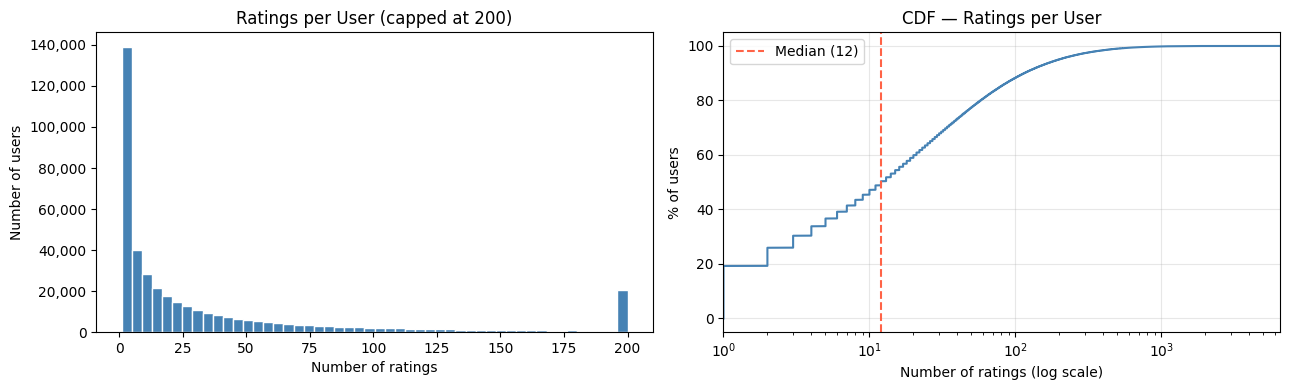

In [ ]:
ratings_per_user = user_ratings.groupby('Username').size()

print("Ratings per user — summary stats")
print(ratings_per_user.describe().rename("ratings/user").to_string())
print()

# Cumulative % of users by threshold
thresholds = [5, 10, 20, 50, 100]
print(f"{'Threshold':<20} {'% of users':>12}")
print("-" * 33)
for t in thresholds:
    pct = (ratings_per_user <= t).mean() * 100
    print(f"<= {t:<17} {pct:>11.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# histogram (capped at 200)
axes[0].hist(ratings_per_user.clip(upper=200), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Ratings per User (capped at 200)")
axes[0].set_xlabel("Number of ratings")
axes[0].set_ylabel("Number of users")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# cumulative distribution
sorted_vals = np.sort(ratings_per_user.values)
cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
axes[1].plot(sorted_vals, cdf * 100, color='steelblue', linewidth=1.5)
axes[1].set_xscale('log')
axes[1].set_xlim(1, sorted_vals.max())
axes[1].set_xlabel("Number of ratings (log scale)")
axes[1].set_ylabel("% of users")
axes[1].set_title("CDF — Ratings per User")
axes[1].axvline(12, color='tomato', linestyle='--', label='Median (12)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Game Popularity — Long Tail

Top 10 most-rated games:


,Ratings,% of all
Game,,
Pandemic,107760,0.569
Carcassonne,107601,0.568
Catan,106725,0.563
7 Wonders,89014,0.470
Dominion,80901,0.427
Ticket to Ride,75352,0.398
Codenames,73188,0.386
Terraforming Mars,72753,0.384
7 Wonders Duel,68063,0.359



Top  1% of games ( 219 titles) → 33.8% of all ratings
Top 10% of games (2192 titles) → 76.7% of all ratings

Games with  <50 ratings : 19.9%
Games with <100 ratings : 43.9%

Catan: 106,725 ratings  (0.563% of all)
Pandemic: 107,760 ratings  (0.569% of all)


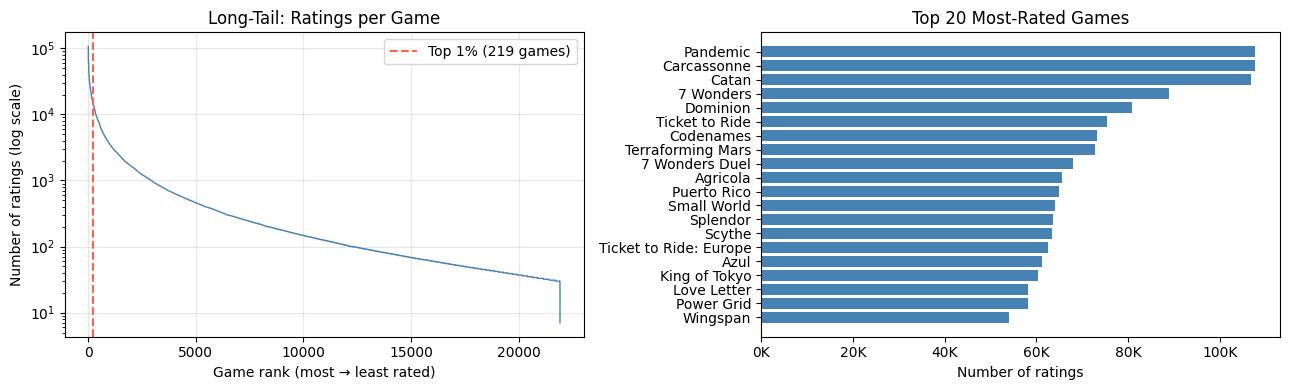

In [ ]:
ratings_per_game = user_ratings.groupby('BGGId').size().sort_values(ascending=False)
total_ratings    = ratings_per_game.sum()
game_names       = games.set_index('BGGId')['Name']

top10 = ratings_per_game.head(10).reset_index()
top10.columns = ['BGGId', 'Ratings']
top10['Game']      = top10['BGGId'].map(game_names)
top10['% of all']  = (top10['Ratings'] / total_ratings * 100).round(3)
print("Top 10 most-rated games:")
display(top10[['Game', 'Ratings', '% of all']].set_index('Game'))

top_1pct        = int(len(ratings_per_game) * 0.01)
top_10pct       = int(len(ratings_per_game) * 0.10)
print(f"\nTop  1% of games ({top_1pct:>4} titles) → {ratings_per_game.head(top_1pct).sum()/total_ratings*100:.1f}% of all ratings")
print(f"Top 10% of games ({top_10pct:>4} titles) → {ratings_per_game.head(top_10pct).sum()/total_ratings*100:.1f}% of all ratings")
print(f"\nGames with  <50 ratings : {(ratings_per_game <  50).mean()*100:.1f}%")
print(f"Games with <100 ratings : {(ratings_per_game < 100).mean()*100:.1f}%\n")

for target in ['Catan', 'Pandemic']:
    bid = games[games['Name'] == target]['BGGId'].values[0]
    cnt = ratings_per_game.get(bid, 0)
    print(f"{target}: {cnt:,} ratings  ({cnt/total_ratings*100:.3f}% of all)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, len(ratings_per_game) + 1), ratings_per_game.values, color='steelblue', linewidth=1)
axes[0].set_yscale('log')
axes[0].set_xlabel("Game rank (most → least rated)")
axes[0].set_ylabel("Number of ratings (log scale)")
axes[0].set_title("Long-Tail: Ratings per Game")
axes[0].axvline(top_1pct, color='tomato', linestyle='--', label=f'Top 1% ({top_1pct} games)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


top20_names = [game_names.get(i, f"ID {i}") for i in ratings_per_game.head(20).index]
top20_vals  = ratings_per_game.head(20).values
axes[1].barh(top20_names[::-1], top20_vals[::-1], color='steelblue')
axes[1].set_xlabel("Number of ratings")
axes[1].set_title("Top 20 Most-Rated Games")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))

plt.tight_layout()
plt.show()

## 4. Rating Scale Distribution

,Value
Metric,
Min,0.0001
Max,10.0
Mean,7.131
Median,7.0
Std Dev,1.543
Fractional ratings,"3,257,791 (17.2%)"


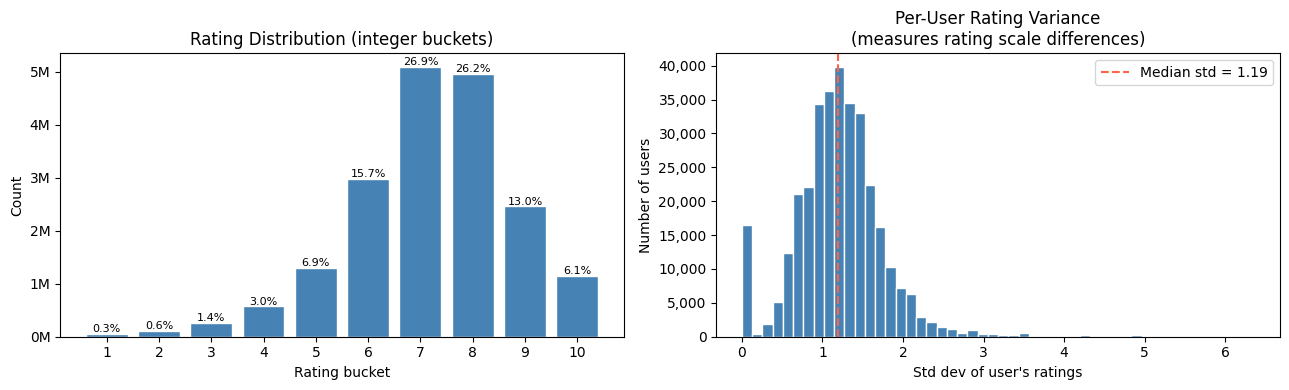

In [ ]:
r = user_ratings['Rating']

# Summary
stats = pd.DataFrame({
    "Metric": ["Min", "Max", "Mean", "Median", "Std Dev", "Fractional ratings"],
    "Value": [
        f"{r.min()}",
        f"{r.max()}",
        f"{r.mean():.3f}",
        f"{r.median():.1f}",
        f"{r.std():.3f}",
        f"{(~r.apply(float.is_integer)).sum():,}  ({(~r.apply(float.is_integer)).mean()*100:.1f}%)"
    ]
})
display(stats.set_index("Metric"))

# Integer-bucket counts
buckets = pd.cut(r, bins=[0,1,2,3,4,5,6,7,8,9,10],
                 labels=['1','2','3','4','5','6','7','8','9','10'])
counts = buckets.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: bar chart by bucket
axes[0].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel("Rating bucket")
axes[0].set_ylabel("Count")
axes[0].set_title("Rating Distribution (integer buckets)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1e6)}M"))
for i, (label, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 30000, f"{cnt/len(r)*100:.1f}%", ha='center', fontsize=8)

# Right: per-user rating std (measures individual bias)
user_std = user_ratings.groupby('Username')['Rating'].std().dropna()
axes[1].hist(user_std, bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel("Std dev of user's ratings")
axes[1].set_ylabel("Number of users")
axes[1].set_title("Per-User Rating Variance\n(measures rating scale differences)")
axes[1].axvline(user_std.median(), color='tomato', linestyle='--',
                label=f'Median std = {user_std.median():.2f}')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

## 5. Content Features Available

mechanics.csv     : 21,925 games × 157 mechanic flags
subcategories.csv : 21,925 games × 10 category flags

Sample mechanics  : ['Alliances', 'Area Majority / Influence', 'Auction/Bidding', 'Dice Rolling', 'Hand Management', 'Simultaneous Action Selection', 'Trick-taking']
Sample categories : ['Exploration', 'Miniatures', 'Territory Building', 'Card Game', 'Educational', 'Puzzle', 'Collectible Components', 'Word Game', 'Print & Play', 'Electronic']



,GameWeight,MinPlayers,MaxPlayers,YearPublished,MfgPlaytime,ComAgeRec
count,21925.00,21925.00,21925.00,21925.00,21925.00,16395.00
mean,1.98,2.01,5.71,1985.49,90.51,10.00
std,0.85,0.69,15.01,212.49,529.66,3.27
min,0.00,0.00,0.00,-3500.00,0.00,2.00
25%,1.33,2.00,4.00,2001.00,25.00,8.00
50%,1.97,2.00,4.00,2011.00,45.00,10.00
75%,2.53,2.00,6.00,2017.00,90.00,12.00
max,5.00,10.00,999.00,2021.00,60000.00,21.00


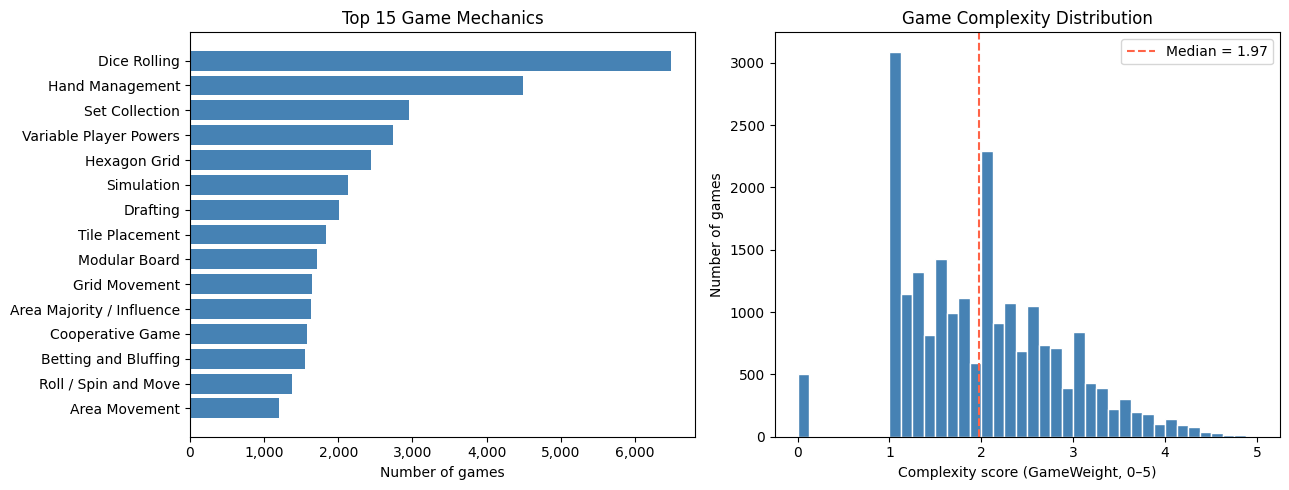

In [ ]:
# Feature overview
print(f"mechanics.csv     : {mechanics.shape[0]:,} games × {mechanics.shape[1]-1} mechanic flags")
print(f"subcategories.csv : {subcategories.shape[0]:,} games × {subcategories.shape[1]-1} category flags\n")
print(f"Sample mechanics  : {mechanics.columns[1:8].tolist()}")
print(f"Sample categories : {subcategories.columns[1:].tolist()}\n")

# Numeric content columns
content_cols = ['GameWeight', 'MinPlayers', 'MaxPlayers', 'YearPublished', 'MfgPlaytime', 'ComAgeRec']
display(games[content_cols].describe().round(2))

# Top mechanics by prevalence
mech_counts = mechanics.drop(columns='BGGId').sum().sort_values(ascending=False)
top_mechs   = mech_counts.head(15)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(top_mechs.index[::-1], top_mechs.values[::-1], color='steelblue')
axes[0].set_xlabel("Number of games")
axes[0].set_title("Top 15 Game Mechanics")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# GameWeight distribution
axes[1].hist(games['GameWeight'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel("Complexity score (GameWeight, 0–5)")
axes[1].set_ylabel("Number of games")
axes[1].set_title("Game Complexity Distribution")
axes[1].axvline(games['GameWeight'].median(), color='tomato', linestyle='--',
                label=f"Median = {games['GameWeight'].median():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()